# **Heart Attack Risk Classification**

**Problem Statement**

The goal of this project is to develop a classification model that can predict the likelihood of a heart attack based on various patient health indicators. The dataset contains information on patients' demographic details, medical history, and diagnostic measures. The primary objective is to accurately classify patients into two categories: those with a higher likelihood of experiencing a heart attack (target = 1) and those with a lower likelihood (target = 0).

**Import libraries**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

**Load data**

In [ ]:
data = pd.read_csv('/content/heart.csv')
data

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


**Domain Analysis**

* Age and sex represent the demographic details of the patients.
* ChestPaintype describes the type of chest pain experienced by the patient.
* RestingBP shows the resting blood pressure level of the patient.
* Cholesterol indicates the cholesterol level in the blood.
* FastingBS represents fasting blood sugar, which helps detect diabetes risk.
* RestingECG shows the electrocardiogram results of the heart.
* MaxHR indicates the maximum heart rate achieved during activity.
* ExcrciseAngina shows whether the patient experiences chest pain during exercise.
* Oldpeak represents ST depression during exercise compared to rest.
* ST_Slope describes the slope of the ST segment during peak exercise.
* HeartDisease is the target variable that indicates whether the patient has heart disease(1) or not(0).


**Basic checks**


In [ ]:
#shape
data.shape

(918, 12)

In [ ]:
#head
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
#tail
data.tail()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1
917,38,M,NAP,138,175,0,Normal,173,N,0.0,Up,0


In [ ]:
#infodata.info()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [ ]:
#dtypes
data.dtypes

,0
Age,int64
Sex,object
ChestPainType,object
RestingBP,int64
Cholesterol,int64
FastingBS,int64
RestingECG,object
MaxHR,int64
ExerciseAngina,object
Oldpeak,float64


In [ ]:
#columns
data.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [ ]:
#num_cols
num_cols=data.select_dtypes(include=['float64','int64'])
num_cols

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
0,40,140,289,0,172,0.0,0
1,49,160,180,0,156,1.0,1
2,37,130,283,0,98,0.0,0
3,48,138,214,0,108,1.5,1
4,54,150,195,0,122,0.0,0
...,...,...,...,...,...,...,...
913,45,110,264,0,132,1.2,1
914,68,144,193,1,141,3.4,1
915,57,130,131,0,115,1.2,1
916,57,130,236,0,174,0.0,1


In [ ]:
#cat_cols
cat_cols=data.select_dtypes(include=['object'])
cat_cols

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
0,M,ATA,Normal,N,Up
1,F,NAP,Normal,N,Flat
2,M,ATA,ST,N,Up
3,F,ASY,Normal,Y,Flat
4,M,NAP,Normal,N,Up
...,...,...,...,...,...
913,M,TA,Normal,N,Flat
914,M,ASY,Normal,N,Flat
915,M,ASY,Normal,Y,Flat
916,F,ATA,LVH,N,Flat


In [ ]:
#describe
for x in cat_cols:
  print(x,'-->',data[x].unique())

Sex --> ['M' 'F']
ChestPainType --> ['ATA' 'NAP' 'ASY' 'TA']
RestingECG --> ['Normal' 'ST' 'LVH']
ExerciseAngina --> ['N' 'Y']
ST_Slope --> ['Up' 'Flat' 'Down']


In [ ]:
#value counts
for x in cat_cols:
  print(data[x].value_counts())

Sex
M    725
F    193
Name: count, dtype: int64
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64
RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64
ExerciseAngina
N    547
Y    371
Name: count, dtype: int64
ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64


# **Data Cleaning**

In [ ]:
#check for missing values
data.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [ ]:
#check for duplicates
data.duplicated().sum()

np.int64(0)

# Exploratory data analysis

**Unuvariate**

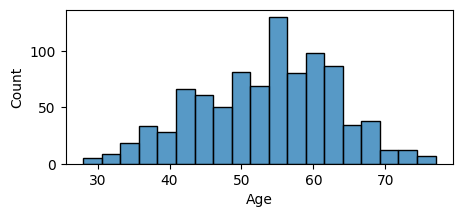

In [ ]:
#check the distribution of age
plt.figure(figsize=(5,2))
sns.histplot(data,x='Age')
plt.show()

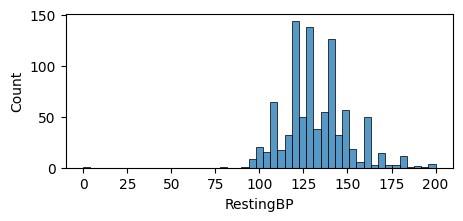

In [ ]:
#check the distribution of RestingBP
plt.figure(figsize=(5,2))
sns.histplot(data,x='RestingBP')
plt.show()

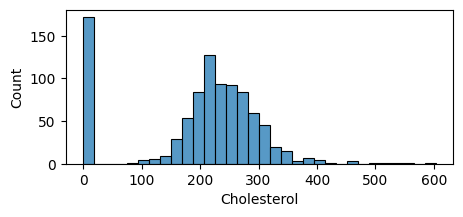

In [ ]:
#check the distribution of Cholestrol
plt.figure(figsize=(5,2))
sns.histplot(data,x='Cholesterol')
plt.show()

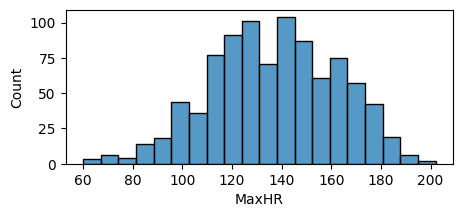

In [ ]:
#check the distribution of MaxHR
plt.figure(figsize=(5,2))
sns.histplot(data,x='MaxHR')
plt.show()

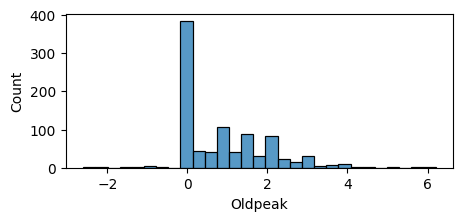

In [ ]:
#check the distribution of Oldpeak
plt.figure(figsize=(5,2))
sns.histplot(data,x='Oldpeak')
plt.show()

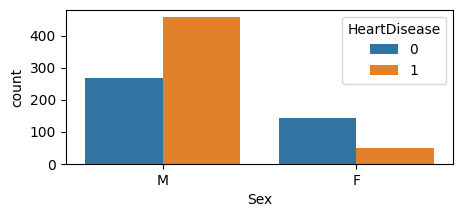

In [ ]:
# count of male and female
plt.figure(figsize=(5,2))
sns.countplot(data,x='Sex',hue='HeartDisease')
plt.show()

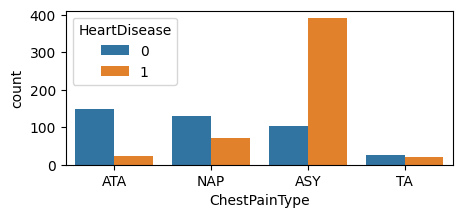

In [ ]:
#count of ChestPainType
plt.figure(figsize=(5,2))
sns.countplot(data,x='ChestPainType',hue='HeartDisease')
plt.show()

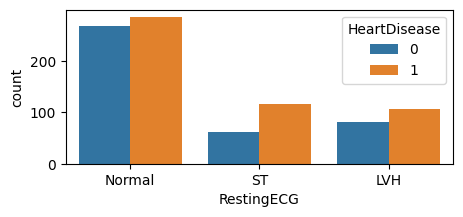

In [ ]:
#count of RestingECG
plt.figure(figsize=(5,2))
sns.countplot(data,x='RestingECG',hue='HeartDisease')
plt.show()

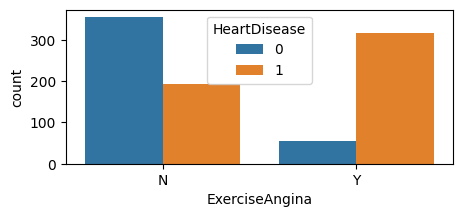

In [ ]:
#count of exerciseAngina
plt.figure(figsize=(5,2))
sns.countplot(data,x='ExerciseAngina',hue='HeartDisease')
plt.show()

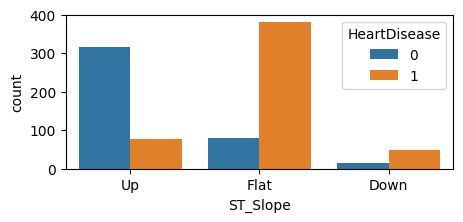

In [ ]:
#ST_Slope
plt.figure(figsize=(5,2))
sns.countplot(data,x='ST_Slope',hue='HeartDisease')
plt.show()

#**Bivariate Analysis**

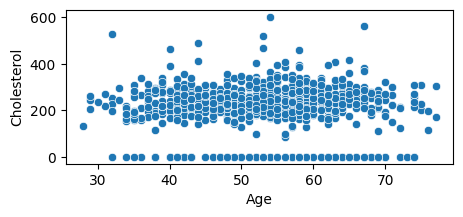

In [ ]:
# age v/s Cholesterol
plt.figure(figsize=(5,2))
sns.scatterplot(data,x='Age',y='Cholesterol')
plt.show()

<Axes: xlabel='Age', ylabel='RestingBP'>

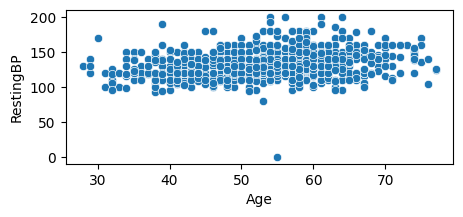

In [ ]:
#age v/s RestingBP
plt.figure(figsize=(5,2))
sns.scatterplot(data,x='Age',y='RestingBP')

<Axes: xlabel='Age', ylabel='MaxHR'>

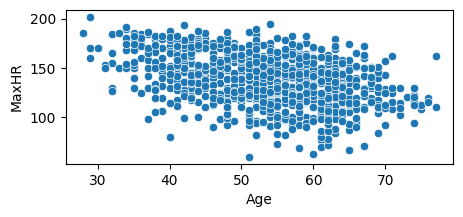

In [ ]:
#age v/s MaxHR
plt.figure(figsize=(5,2))
sns.scatterplot(data,x='Age',y='MaxHR')

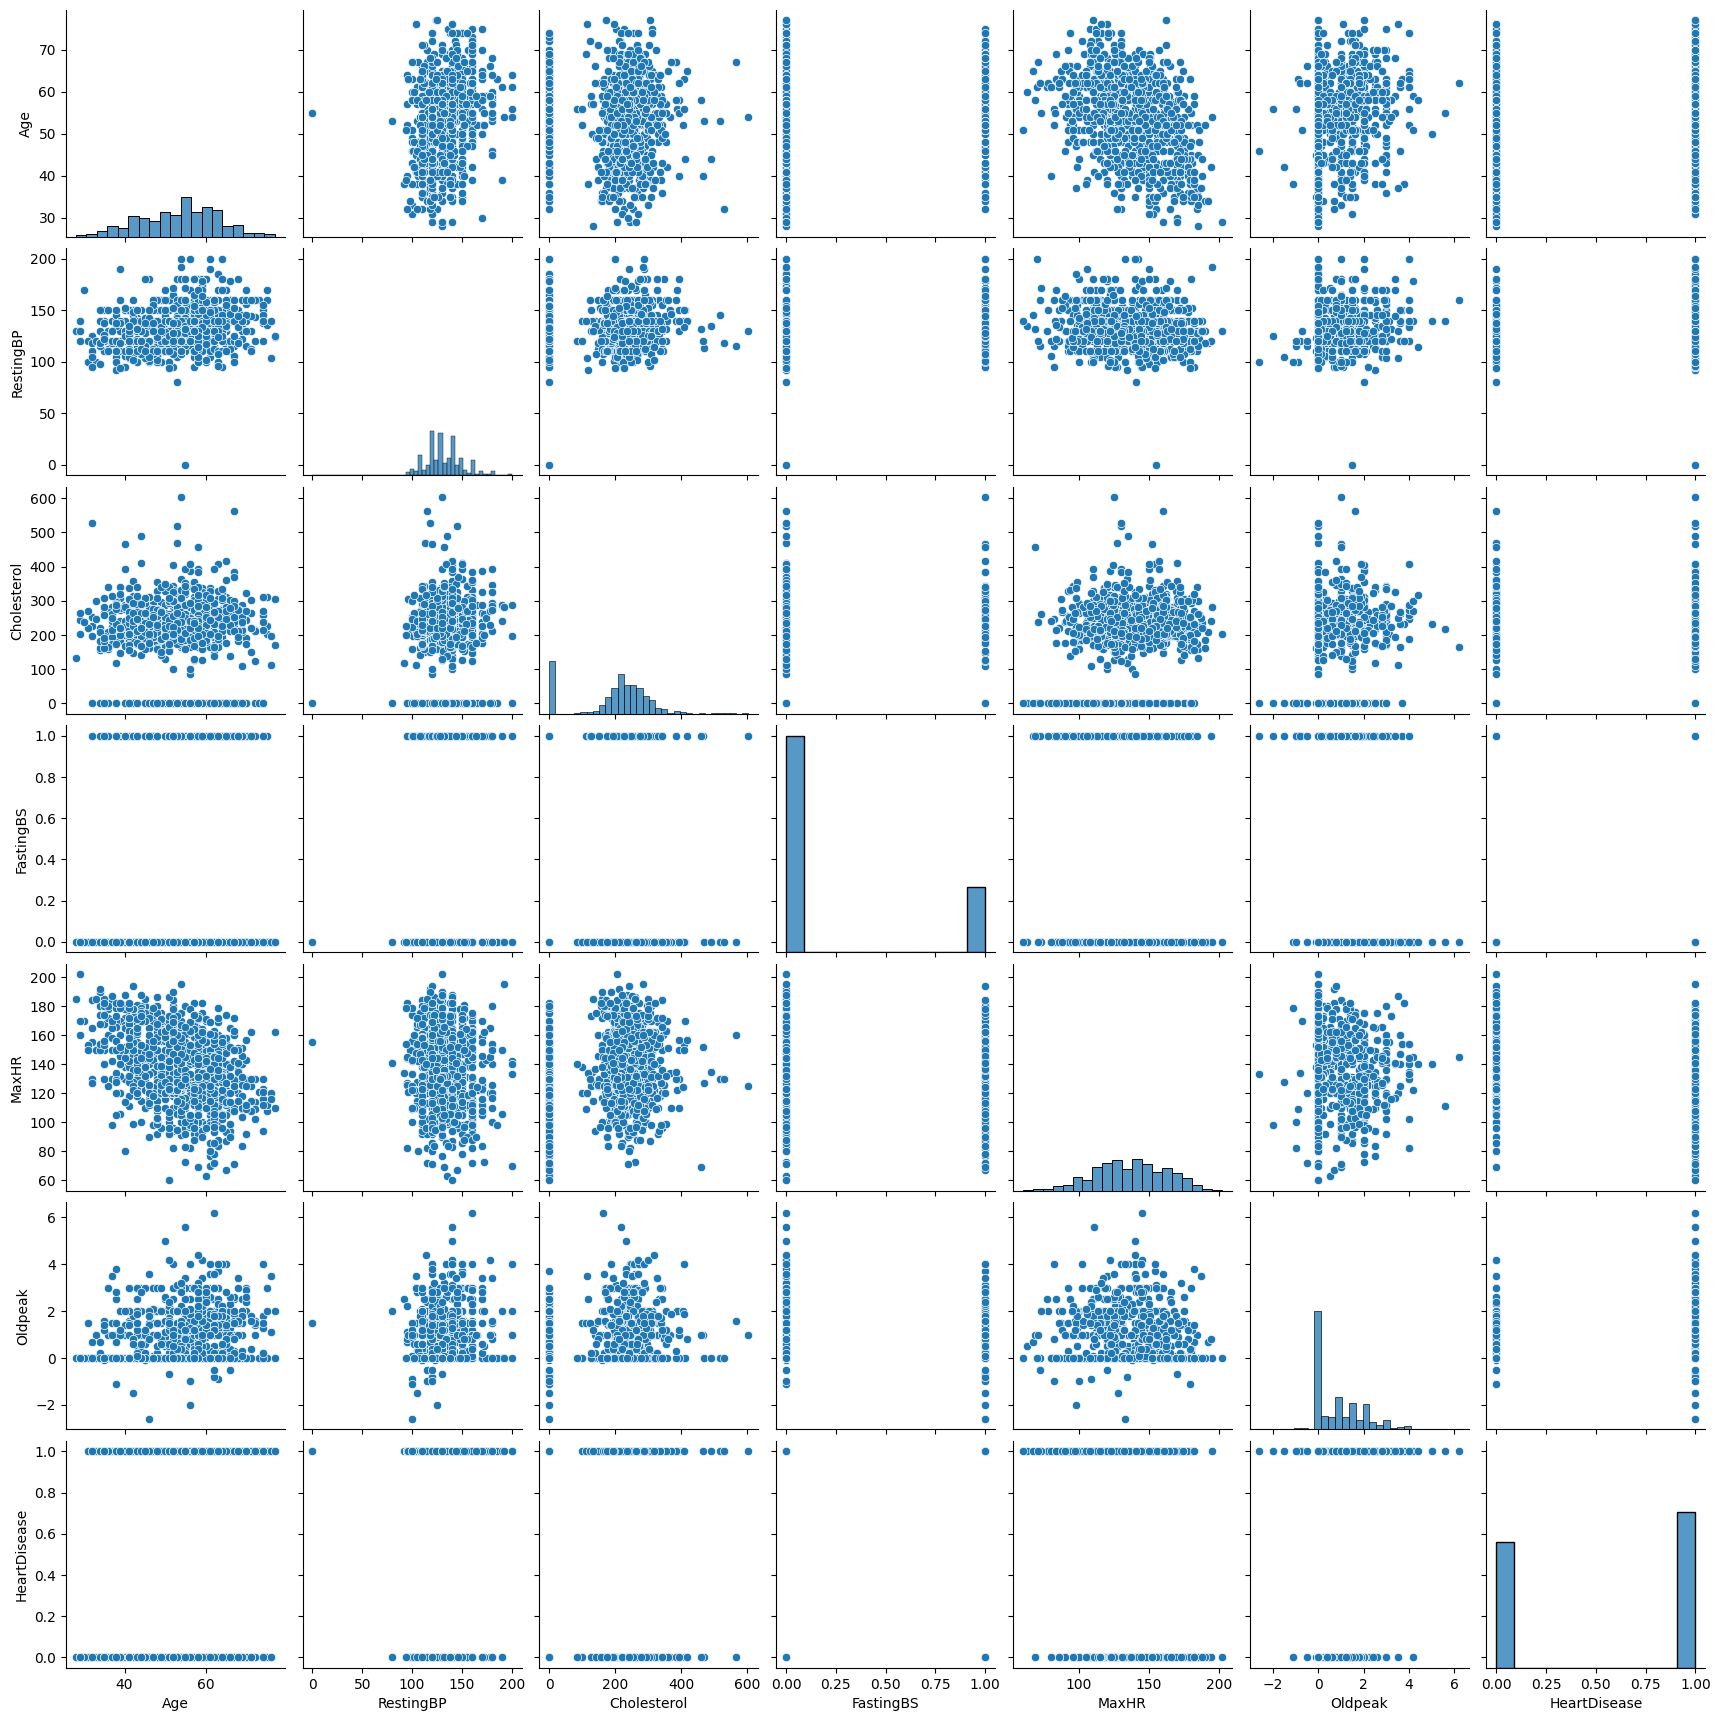

In [ ]:
sns.pairplot(data)

**Heat Map**

In [ ]:
num_cols.corr()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
Age,1.000000,0.254399,-0.095282,0.198039,-0.382045,0.258612,0.282039
RestingBP,0.254399,1.000000,0.100893,0.070193,-0.112135,0.164803,0.107589
Cholesterol,-0.095282,0.100893,1.000000,-0.260974,0.235792,0.050148,-0.232741
FastingBS,0.198039,0.070193,-0.260974,1.000000,-0.131438,0.052698,0.267291
MaxHR,-0.382045,-0.112135,0.235792,-0.131438,1.000000,-0.160691,-0.400421
Oldpeak,0.258612,0.164803,0.050148,0.052698,-0.160691,1.000000,0.403951
HeartDisease,0.282039,0.107589,-0.232741,0.267291,-0.400421,0.403951,1.000000


<Axes: >

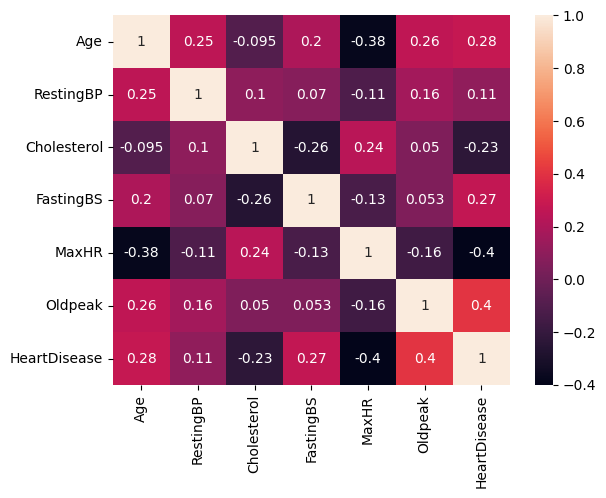

In [ ]:
sns.heatmap(num_cols.corr(),annot=True)

**Handle Outliers**

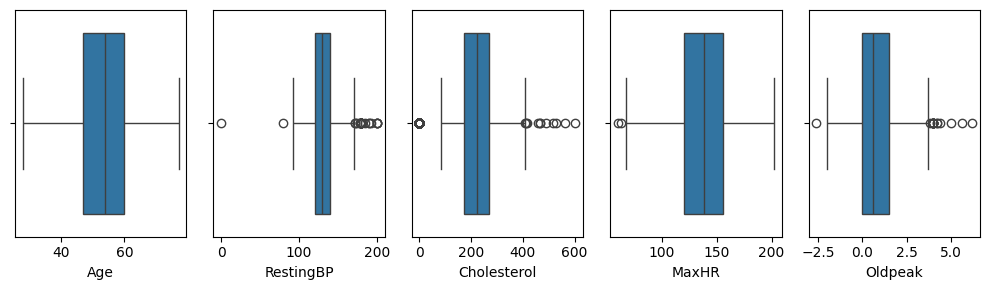

In [ ]:
# check outliers
fig,ax = plt.subplots(1,5 , figsize=(10,3))
sns.boxplot(data,x='Age',ax=ax[0])
sns.boxplot(data,x='RestingBP',ax=ax[1])
sns.boxplot(data,x='Cholesterol',ax=ax[2])
sns.boxplot(data,x='MaxHR',ax=ax[3])
sns.boxplot(data,x='Oldpeak',ax=ax[4])
plt.tight_layout()




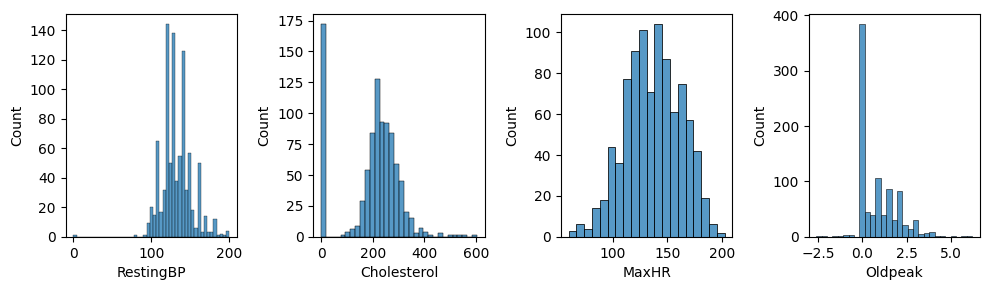

In [ ]:
# check the distribution
fig,ax = plt.subplots(1,4 , figsize=(10,3))
sns.histplot(data,x='RestingBP',ax=ax[0])
sns.histplot(data,x='Cholesterol',ax=ax[1])
sns.histplot(data,x='MaxHR',ax=ax[2])
sns.histplot(data,x='Oldpeak',ax=ax[3])
plt.tight_layout()

In [ ]:
A =['RestingBP','Cholesterol','MaxHR','Oldpeak']
for x in A:
  print(x,'-->',data[x].skew())

RestingBP --> 0.1798393100516288
Cholesterol --> -0.6100864307268192
MaxHR --> -0.14435941846180994
Oldpeak --> 1.0228720218107528


- restingBP , MaxHR distribution is normal as its skewness is between [-0.5,0.5]
- Cholesterol and Oldpeak is skewed

In [ ]:
#Resting, MaxHR use 3 sigma rule

**Cholesterol**

In [ ]:
# IQR
Q1 = data.loc[:,'Cholesterol'].quantile(0.25)
Q3 = data.loc[:,'Cholesterol'].quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1-1.5*IQR
upper_limit = Q3 + 1.5 *IQR


In [ ]:
len(data[(data.loc[:,'Cholesterol']>upper_limit) | (data.loc[:,'Cholesterol']<lower_limit)])/len(data)*100

19.934640522875817

**Oldpeak**

In [ ]:
Q1 = data.loc[:,'Oldpeak'].quantile(0.25)
Q3 = data.loc[:,'Oldpeak'].quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1-1.5*IQR
upper_limit = Q3 + 1.5 *IQR

In [ ]:
data[(data.loc[:,'Oldpeak']>upper_limit) | (data.loc[:,'Oldpeak']<lower_limit)]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
68,52,M,ASY,160,246,0,ST,82,Y,4.0,Flat,1
166,50,M,ASY,140,231,0,ST,140,Y,5.0,Flat,1
324,46,M,ASY,100,0,1,ST,133,N,-2.6,Flat,1
500,65,M,ASY,136,248,0,Normal,140,Y,4.0,Down,1
521,61,M,ASY,120,282,0,ST,135,Y,4.0,Down,1
537,74,M,ASY,150,258,1,ST,130,Y,4.0,Down,1
559,64,M,ASY,134,273,0,Normal,102,Y,4.0,Down,1
624,63,F,ASY,150,407,0,LVH,154,N,4.0,Flat,1
702,59,M,TA,178,270,0,LVH,145,N,4.2,Down,0
732,56,F,ASY,200,288,1,LVH,133,Y,4.0,Down,1


In [ ]:
len(data[(data.loc[:,'Oldpeak']>upper_limit) | (data.loc[:,'Oldpeak']<lower_limit)])/len(data)*100

1.7429193899782136

In [ ]:
data.loc[(data.loc[:,'Oldpeak']>upper_limit) |
 (data.loc[:,'Oldpeak']<lower_limit),'Oldpeak']=data.loc[:,'Oldpeak'].median()

**RestingBP**

In [ ]:
mean_val = data.loc[:,'RestingBP'].mean()
std_val =data.loc[:,'RestingBP'].std()
lower_limit= mean_val - 3* std_val
upper_limit= mean_val + 3*std_val

In [ ]:
data[(data.loc[:,'RestingBP']>upper_limit)|(data.loc[:,'RestingBP']<lower_limit)]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
109,39,M,ATA,190,241,0,Normal,106,N,0.0,Up,0
241,54,M,ASY,200,198,0,Normal,142,Y,2.0,Flat,1
365,64,F,ASY,200,0,0,Normal,140,Y,1.0,Flat,1
399,61,M,NAP,200,0,1,ST,70,N,0.0,Flat,1
449,55,M,NAP,0,0,0,Normal,155,N,1.5,Flat,1
592,61,M,ASY,190,287,1,LVH,150,Y,2.0,Down,1
732,56,F,ASY,200,288,1,LVH,133,Y,0.6,Down,1
759,54,M,ATA,192,283,0,LVH,195,N,0.0,Up,1


In [ ]:
data.loc[(data.loc[:,'RestingBP']>upper_limit)|
 (data.loc[:,'RestingBP']<lower_limit),'RestingBP']=data.loc[:,'RestingBP'].mean()

/tmp/ipykernel_785/734573612.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '132.39651416122004' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[(data.loc[:,'RestingBP']>upper_limit)|


**MaxHR**

In [ ]:
mean_val = data.loc[:,'MaxHR'].mean()
std_val =data.loc[:,'MaxHR'].std()
lower_limit= mean_val - 3* std_val
upper_limit= mean_val + 3*std_val

In [ ]:
data[(data.loc[:,'MaxHR']>upper_limit)|(data.loc[:,'MaxHR']<lower_limit)]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
390,51,M,ASY,140.0,0,0,Normal,60,N,0.0,Flat,1


In [ ]:
data.loc[(data.loc[:,'MaxHR']>upper_limit)|
 (data.loc[:,'MaxHR']<lower_limit),'MaxHR']=data.loc[:,'MaxHR'].mean()

/tmp/ipykernel_785/3454964119.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '136.80936819172112' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[(data.loc[:,'MaxHR']>upper_limit)|
